# 1. Finite element method (FEM 1D)

It is a method for an approximate solution of an PDE.

The finite element method (FEM) breaks the space up into multiple geometric elements, determinines an approximate form for the solution appropiate to each element, and then matches the solution up at the domain edges. Although finite differences are simpler to implement than FEM, they are less robust mathematically and les efficiente in terms of computer time for big problems. The FEM with varios preprogramed multigird packages has a very much become the standar for large scale and practical applications.

**Example: The Poisson's equation**


$$-\dfrac{d^2 U(x)}{dx^2}= 4\pi\rho(x)\hspace{1 cm} 0\leq x\leq 1$$
with $\rho = \dfrac{1}{4\pi}$ as a aparticular case, the EDO is

$$-\dfrac{d^2 U(x)}{dx^2}= 1\hspace{1 cm} 0\leq x \leq 1$$

with Dirichlet conditions $U(0)=0, U(1)=1$, the solution is $U(x)=-\dfrac{x}{2}(x-3)$. Let's compute the solution using FEM as an ilustration.


In a FEM, the domain in which the PDE is solved is split into
finite subdomains, called **elements**, and a trial solution to the PDE in each subdomain is hypothesized.
Then the parameters of the trial solution are adjusted to
obtain a best fit (“Solving Systems of Equations with Matrices; Data Fitting”) to the exact solution.
The numerically intensive work is in finding the best values for these parameters and in matching the trial solutions
for the different subdomains.

A FEM solution follows six basic steps:

1. Derivation of a **weak form of the PDE**. This is equivalent to a least-squares
minimization of the integral of the difference between the approximate and
exact solutions.
2. Discretization of the computational domains.
3. Generation of interpolating or trial functions.
4. Assembly of the stiffness (rigidez) matrix and load vector.
5. Implementation of the boundary conditions.
6. Solution of the resulting linear system of equations.

## Weak form of PDF

Let's use the Posisson's equation as example. We assume that we have an approximate or **trial solution $\Phi(x)$** that vanishes at the
endpoints, $\Phi(a) = \Phi(b) = 0$ (we satisfy the boundary conditions later). We multiply both sides of the diffrerential equation

$$-\frac{d^{2}U(x)}{dx^{2}}\Phi(x) = 4\pi\,\rho(x)\,\Phi(x)$$

Integrating by parts we get the weak form:

\begin{align*}
- \int_a^b dx \, \frac{d^2 U(x)}{dx^2} \, \Phi(x)
&= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x), \\[6pt]
- \left. \frac{dU(x)}{dx} \Phi(x) \right|_a^b
+ \int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
&= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
\end{align*}

$$\int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
\tag{1}
$$

## Galerkin spectral decomposition

We realize an stepwise procedure. We split the full domain of the PDE into subdomains (elements), find approximate
solutions within each element, and then match the elemental solutions onto each other. For our **1-D problem** the subdomain elements are straight lines of equal length: $x=(x_0,x_1, 0\cdots,x_i\cdots,x_N)$, $N$ elements and $N+1$ nodes, while for a **2-D problem**, the elements can be *parallelograms or triangles*, etc.

We proposed an expansion of $U(x)$ in terms of a set of **basis** functions $\phi_i(x)$ :

$$U(x)=\sum_{j=0}^{N-1}\alpha_j\phi_j(x) \tag{2}$$

This expansion is called a spectral decomposition (in order to satisfy the boundary conditions, we will later add another term to the expansion). If the sizes of the finite elements are made sufficiently small, then good accuracy is obtained
with simple piecewise-continuous basis functions, such as the **triangles or hat** in Figure

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/triangle.png" alt="A set of overlapping triangles" width="800" height="250">

we use basis functions $\phi_i$ that form a triangle or “hat” between $x_{i-1}$ and $x_{i+1}$ and equal 1 at :

\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_i}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\tag{3}
\end{equation}

Because we have chosen $\phi_i(x_i) = 1$, the values of the expansion coefficients $\alpha_i$
equal the values of the solution at the nodes (to-be-determined) :

\begin{equation}
U(x_i) = \sum_{i=0}^{N-1} \alpha_i \phi_i(x_i)
= \alpha_i,
\tag{4}
\end{equation}

\begin{equation}
\Rightarrow \quad U(x) = \sum_{j=0}^{N-1} U(x_j)\,\phi_j(x).
\tag{5}
\end{equation}

Consequently, you can think of the hat functions as **linear interpolations** between
the solution at the nodes.
Let's find the $\alpha$ coeffitients.

## Solution via Linear equations

Inserting $U(x)$ in eq.(1) convert the problem into matrix problem:

\begin{equation}
\int_a^b dx \, \frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x) \right)
\frac{d\Phi}{dx}
=
\int_a^b dx \, 4\pi \rho(x)\, \Phi(x).
\end{equation}

By successively selecting $\Phi(x) = \phi_0, \ldots, \phi_{N-1}$, we obtain $N$ simultaneous linear equations for the unknown $\alpha_j$’s:

\begin{equation}
\int_a^b dx \,\bigg(\frac{d\phi_i}{dx}\bigg) \frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x) \right)
=
\int_a^b dx \, 4\pi \rho(x)\, \phi_i(x),
\quad i = 0,1 \ldots, N-1.
\tag{7}
\end{equation}

We factor out the unknown $\alpha_j$ and write out the equations explicitly:

$$
\begin{align*}
&\alpha_0 \int_a^b \phi_{0}' \phi_{0}' \, dx
+ \alpha_1 \int_a^b \phi_{0}' \phi_{1}' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{0}' \phi_{N-1}' \, dx
= \int_a^b 4\pi \rho \, \phi_0 \, dx, \\[6pt]
&\alpha_0 \int_a^b \phi_{1}' \phi_{0}' \, dx
+ \alpha_1 \int_a^b \phi_{1}' \phi_{0}' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_1' \phi_{N-1}' \, dx
= \int_a^b 4\pi \rho \, \phi_1 \, dx, \\
&\vdots \\
&\alpha_0 \int_a^b \phi_{N-1}' \phi_{0}' \, dx
+ \alpha_1 \int_a^b \phi_{N-1}' \phi_{1}' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{N-1}' \phi_{N-1}' \, dx
= \int_a^b 4\pi \rho \, \phi_{N-1} \, dx.
\end{align*}
$$

Because we have chosen the $\phi_i$’s to be the simple hat functions, the derivatives are easy to evaluate analytically (otherwise they can be done numerically):

\begin{equation}
\frac{d\phi_{i,i+1}}{dx} =
\begin{cases}
0, & x < x_{i-1}, \text{ or } x_{i+1} < x, \\[6pt]
\dfrac{1}{h_{i-1}}, & x_{i-1} \le x \le x_i, \\[10pt]
-\dfrac{1}{h_i}, & x_i \le x \le x_{i+1},
\end{cases}
\qquad
\begin{cases}
0, & x < x_i, \text{ or } x_{i+2} < x, \\[6pt]
\dfrac{1}{h_{i}}, & x_i \le x \le x_{i+1}, \\[10pt]
-\dfrac{1}{h_{i+1}}, & x_{i+1} \le x \le x_{i+2}.
\end{cases}
\tag{8}
\end{equation}

The integrals to evaluate are:

$$
\begin{align*}
\int_{x_{i-1}}^{x_{i+1}} dx \, (\phi_{i'})^2
&= \int_{x_{i-1}}^{x_i} dx \, \frac{1}{h_{i-1}^2}
+ \int_{x_i}^{x_{i+1}} dx \, \frac{1}{h_i^2}
= \frac{1}{h_{i-1}} + \frac{1}{h_i}, \\[8pt]
\int_{x_{i-1}}^{x_{i+1}} dx \, \phi_{i'} \phi_{i+1}'
&= \int_{x_i}^{x_{i+1}} dx \, \phi_{i'} \phi_{i+1}'
= \int_{x_i}^{x_{i+1}} dx \, \frac{-1}{h_i^2}
= -\frac{1}{h_i}, \\[8pt]
\int_{x_{i-1}}^{x_{i+1}} dx \, (\phi_{i+1}')^2
&= \int_{x_i}^{x_{i+1}} dx \, (\phi_{i+1}')^2
+ \int_{x_{i+1}}^{x_{i+2}} dx \, \frac{1}{h_{i+1}^2}
= \frac{1}{h_i} + \frac{1}{h_{i+1}}.
\end{align*}
$$

We rewrite these equations in the standard matrix form with $\boldsymbol{\alpha}$ constructed
from the unknown $\alpha_j$’s, and the tridiagonal stiffness (rigidez) matrix $\mathbf{A}$ constructed from
the integrals above.


The system can be written in matrix form as

$$\mathbf{A}\,\boldsymbol{\alpha} = \mathbf{b},
$$

where $\boldsymbol{\alpha} = (\alpha_0, \alpha_1, \dots, \alpha_{N-1})^T$ and
$\mathbf{b} = (b_0, b_1, \dots, b_{N-1})^T$ with
$b_i = \int_a^b 4\pi \rho(x)\,\phi_i(x)\,dx.$

The stiffness matrix $\mathbf{A}$ is tridiagonal and given by

$
\mathbf{A}_{N\times N} =
\begin{pmatrix}
\frac{1}{h_0} + \frac{1}{h_1} & -\frac{1}{h_1} & 0 & \cdots & 0 \\
-\frac{1}{h_1} & \frac{1}{h_1} + \frac{1}{h_2} & -\frac{1}{h_2} & \cdots & 0 \\
0 & -\frac{1}{h_2} & \frac{1}{h_2} + \frac{1}{h_3} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & -\frac{1}{h_{N-2}} \\
0 & 0 & 0 & -\frac{1}{h_{N-2}} & \frac{1}{h_{N-2}} + \frac{1}{h_{N-1}}
\end{pmatrix}.
$

In compact form, the entries of $\mathbf{A}$ are
$
A_{i,i} = \frac{1}{h_{i+1}} + \frac{1}{h_i}, \quad
A_{i,i+1} = -\frac{1}{h_i}, \quad
A_{i,i-1} = -\frac{1}{h_{i}}.$
Note that the elements in $A$ are just combinations of inverse step sizes and do no change for different charge density $\rho(x)$.

## Dirichlet Boundary Conditions

Because the basis functions vanish at the endpoints ($\Phi(a) = \Phi(b) = 0$), a solution expanded in them
also vanishes there. This will not do in general, and so we add the particular
solution $U_a\phi_0(x)$ and $U_b\phi_{N}(x)$ , which satisfies the boundary conditions:

$U(x)=\sum_{j=0}^{N-1}\alpha_j \, \phi_j(x) + U_a\,\phi_0(x) +U_b\,\phi_{N}(x)$,
where $U_i=U(x_i)$.

Lets consider the weak form considering the boundary condition $U_a\phi_0(x)$:

$$\int_a^b dx \, \frac{dU(x)}{dx} \, \Phi'(x)
= \int_a^b dx \, 4\pi \rho(x) \, \Phi(x).
$$

\begin{equation}
\int_a^b dx \, \Phi'\frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x)+U_a \, \phi_0(x) \right)
=
\int_a^b dx \, 4\pi \rho(x)\, \Phi(x).
\end{equation}


\begin{align*}
&\alpha_0\int_a^b \phi_0' \phi_0' \, dx
+ \alpha_1 \int_a^b \phi_0' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_0' \phi_{N-1}' \, dx +  U_a\int_a^b \phi_0' \phi_0' \, dx
= \int_a^b 4\pi \rho \, \phi_0 \, dx \\[6pt]
&\alpha_0 \int_a^b \phi_1' \phi_0' \, dx
+ \alpha_1\int_a^b \phi_1' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_1' \phi_{N-1}' \, dx  +  U_a\int_a^b \phi_1' \phi_0' \, dx
= \int_a^b 4\pi \rho \, \phi_1 \, dx, \\
\vdots \\
&\alpha_0 \int_a^b \phi_{N-1}' \phi_0' \, dx
+ \alpha_1 \int_a^b \phi_{N-1}' \phi_1' \, dx
+ \cdots
+ \alpha_{N-1} \int_a^b \phi_{N-1}' \phi_{N-1}' \, dx  +  U_a\int_a^b \phi_{N-1}' \phi_0' \, dx
= \int_a^b 4\pi \rho \, \phi_{N-1} \, dx.
\end{align*}

At the end of the day the system still has the form A'y = b' but now with:

\begin{equation}
\mathbf{A'} = \begin{pmatrix}
1 & 0 & \cdots & 0 \\
0 & A_{0,0} & \cdots & A_{0,N-1} \\
 & \ddots & & \\
0 & A_{N-1,0} & \cdots & A_{N-1,N-1}
\end{pmatrix}, \quad
\mathbf{b}' = \begin{pmatrix}
U_a\\
b_1 - A_{0,0}U_a \\
\vdots \\
b_{N-1} - A_{N-1,0}U_a
\end{pmatrix}.
\end{equation}

This is equivalent to adding a new element and changing the load vector: $b'_i = b_i - A_{i,0} U_a , i = 1, . . . , N - 1$, $b'_0 = U_a$.

To impose the boundary condition at $x = b$, we again add a term and substitute into the weak form to obtain
$b'_i = b_i − A_{i,N −1} U_b, i = 0, . . . , N − 1$ and $b'_N = U_b$ to get an $N+1\times N+1$ system:

\begin{equation}
\mathbf{A'} = \begin{pmatrix}
1 & 0 & \cdots & 0 & 0\\
0 & A_{0,0} & \cdots & A_{0,N-1} & 0\\
 & \ddots & & \\
0 & A_{N-1,0} & \cdots & A_{N-1,N-1} & 0 \\
0 & 0 & \cdots & 0 & 1
\end{pmatrix}, \quad
\mathbf{b}' = \begin{pmatrix}
U_a\\
b_1 - A_{0,0}U_a - A_{0,N-1}U_b \\
\vdots \\
b_{N-1} - A_{N-1,0}U_a- A_{N-1,N-1}U_b \\
U_b
\end{pmatrix}.
\end{equation}

For 1-D problems, 100–1000 equations are common, while for 3-D problems there may be millions. Because the
number of calculations varies approximately as $N^2$ , it is important to employ an
efficient and accurate algorithm because round-off error can easily accumulate after thousands of steps. We recommend one from a scientific subroutine library for solving systems of equations with matrices.

**Example 1: FEM Implementation - Poison's equation**

$$\boxed{-\dfrac{d^2 u(x)}{dx^2}= 4\pi\rho(x)\hspace{1 cm} 0\leq x\leq 1\,}$$
with $\rho = \dfrac{1}{4\pi}$ we have:  $-\dfrac{d^2 u(x)}{dx^2}= 1\hspace{1 cm} 0\leq x \leq 1\,,$
with Dirichlet conditions $u(0)=0, u(1)=1$.


1. Examine the FEM solution for the choice of parameters $a = 0, b = 1,  U_a = 0,  U_b = 1.$
2. Generate the grid by assigning explicit x values at the nodes over the interval $[0, 1]$.
3. Examine the stiffness matrix A and ensure that it is triangular.
4. Verify that the integrations used to compute the load vector $b$ are accurate (in this example we used `quad`).
5. Verify that the solution of the linear equation $A'\alpha = b'$ is correct.
6. Do the interpolation.
7. Plot the numerical solution for $U(x)$ and compare with the analytic solution.

In [4]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

In [20]:
#N is the number of elements, h is the step size. N+1 are the nodos
N = 5; h = 1/N
print('h=',h)
u = np.zeros(N+1 , float)
b = np.zeros(N+1 , float)

#steps: elements, malla
xi = np.zeros(N+1 , float)
for i in range(0,N+1):
    xi[i] = i*h

print('xi=',xi)

# A matrix (integrated analytical)
A = np.zeros((N+1, N+1), float)

#Triangular matrix
A[0,0]= 2/h
for i in range(1, N+1):
    A[i,i] = 2/h
    A[i,i-1] = -1/h
    A[i-1,i] = -1/h

print('Ai=\n',A)    

#Initial conditions
A[0,0] = 1; A[0,1] = 0; A[1,0] = 0
A[N, N] = 1; A[N, N-1] = 0; A[N-1, N] = 0

print('Af:\n',A)  

h= 0.2
xi= [0.  0.2 0.4 0.6 0.8 1. ]
Ai=
 [[10. -5.  0.  0.  0.  0.]
 [-5. 10. -5.  0.  0.  0.]
 [ 0. -5. 10. -5.  0.  0.]
 [ 0.  0. -5. 10. -5.  0.]
 [ 0.  0.  0. -5. 10. -5.]
 [ 0.  0.  0.  0. -5. 10.]]
Af:
 [[ 1.  0.  0.  0.  0.  0.]
 [ 0. 10. -5.  0.  0.  0.]
 [ 0. -5. 10. -5.  0.  0.]
 [ 0.  0. -5. 10. -5.  0.]
 [ 0.  0.  0. -5. 10.  0.]
 [ 0.  0.  0.  0.  0.  1.]]



\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_i}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\tag{3}
\end{equation}

In [21]:
# to integrate
from scipy import interpolate
import scipy.integrate as integrate

#phi(x) functions
def lin1(x, x1, x2):
    return (x-x1)/(x2-x1)

def lin2(x, x1, x2):
    return (x2-x)/(x2-x1)

#integrals for bi elements using quad
def int1(min, max):
    return integrate.quad(lambda x: lin1(x, min, max), min, max)[0]

def int2(min, max):
    return integrate.quad(lambda x: lin2(x, min, max), min, max)[0]

In [22]:
# b matrix (Numerical integration)
b = np.zeros(N+1, float)

for i in range(1 , N+1):
    b[i-1] = b[i-1] + int2( xi[i-1], xi[i] )
    b[i] = b[i] + int1( xi[i-1], xi[i] )

#print('bi=\n',b)

#Initial conditions
Ua=0; Ub=1

for i in range(1 , N) :
    b[i] = b[i] - Ua*A[i+1,1] # no hace nada
    b[i] = b[i] - Ub*A[i-1,N-1] #good
    #b[i] = b[i] - Ub*A[i,N-1] # Warning

b[0] = Ua; b[N] = Ub

print('bf=\n',b)

bf=
 [0.  0.2 0.2 0.2 5.2 1. ]


In [23]:
# Solve the system using Gaussian elimination in numpy
sol = np.linalg.solve(A, b )
sol

array([0.  , 0.28, 0.52, 0.72, 0.88, 1.  ])

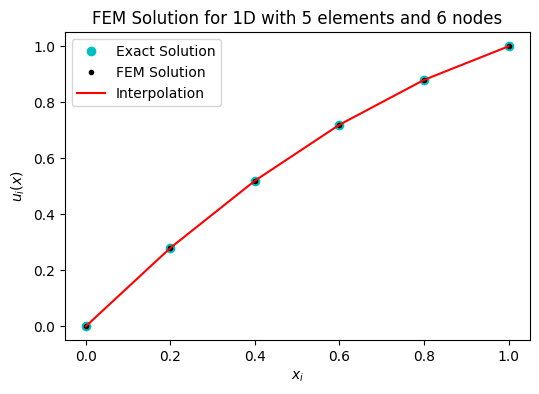

In [24]:
x_new = np.linspace(0,1)
y_new = np.interp(x_new, xi, sol)

#Plot the solution with FEM and analytical sol
def exact( x ):
    u = - x*(x - 3)/2
    return u

plt.figure(figsize=(6, 4))
plt.plot(xi, exact(xi),'co', label='Exact Solution')
plt.plot(xi, sol,'k.', label='FEM Solution')
plt.plot(x_new, y_new,'r-', label='Interpolation')
plt.title('FEM Solution for 1D with %1d elements and %d nodes' % (N, N+1))
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()

**Example 2: Solve the EDO:**

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$ 
in $0\le x\le 1$, with $U(0)=U(1)=0$. 

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

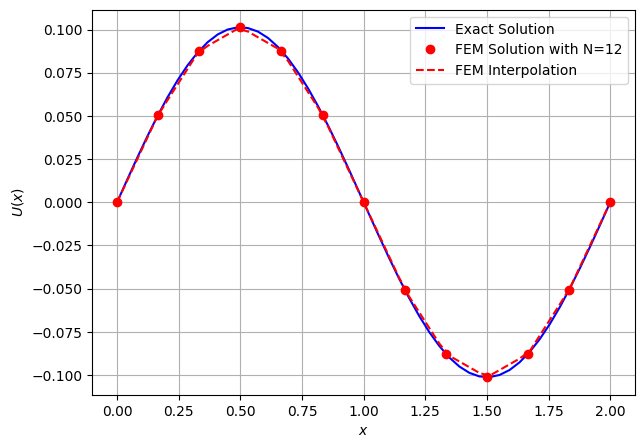

In [25]:
# In this case we know the solution
def exact(x):
    u = (1./np.pi**2)*np.sin(np.pi*x)
    return u

# F funtion: Charge density
def g(x):
  return np.sin(np.pi*x)

#Import my own rutine (Exercise Lab 6)
from FEM_1D import *

#FEM Solution
xa, xb = 0, 2 #Initial conditions
x_new = np.linspace(xa,xb)
# Number of nodos
N = 12
FEM_solution = FEM(N,g,xa,xb,0,0)
x_int, y_int = FEM_solution[0], FEM_solution[1]
#Interpolation
y_new = np.interp(x_new, x_int, y_int)

#Plot the solution with FEM and analytical sol
plt.figure(figsize=(7, 5))
x = np.linspace(xa,xb)
plt.plot(x, exact(x),'b-', label='Exact Solution')
plt.plot(x_int, y_int,'ro', label='FEM Solution with N=%.1d'%N)
plt.plot(x_new, y_new,'r--', label='FEM Interpolation')
plt.xlabel(r'$x$')
plt.ylabel(r'$U(x)$')
plt.legend(loc='best')
plt.grid()
plt.show()

**Exercise: solve the EDO**

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e+e^x(2-x)-x
\end{equation}

**Referencias:**
- Rubin H Landau, Manuel J. Páez, Cristian BOrdeianu, Computational Physics, 3rd Ed, (2015), Wiley VCH, Winheim, Germany.
- Hughes, T.J.R. "The Finite Element Method: Linear Static and Dynamic Finite Element Analysis"
- Zienkiewicz, O.C. "The Finite Element Method"

---

# 2. Finite element method (FEM 2D)

**Example: How to Solve the 2D Poisson Equation**

see: https://medium.com/@ariel.yaniv/finite-element-method-explained-how-to-solve-the-2d-poisson-equation-part-ii-7179a4871b98

While the concepts are similar to 1D, higher dimensions add complexity. 

### The Two-Dimensional Poisson Equation and Its Weak Formulation

Poisson’s equation is an elliptic partial differential equation. 

$\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2}=\nabla^2 u(x,y)= -f(x,y)$  in $\Omega$ region.

Multiplying the equation with a test function, $v(x, y)\approx\phi_i$, and integrating it over the entire surface domain. As we see in 1D, the integration by parts or the repeated integration by parts is used to eliminate the second derivative. Its weak form is:

\begin{equation}
\int_\Omega \nabla v \cdot \nabla u\, d\Omega - \int_{\Gamma} v\nabla u\cdot \vec{n}\, d\Gamma = \int_\Omega v f\cdot d\Omega
\end{equation}

Where $\vec{n}$ is normal to the boundary unit vector in an outward direction. The $\Gamma$ refers to an integration over boundary, which is a line integral in two dimensions. 

If the gradient value of u on the boundary is known, it will be used as a boundary condition (Neumann).




### 2D Weak Formulation

In the one-dimensional case, each node i has one **shape function, Ψi(x)** $=\phi_i(x)$. The shape function in one dimension is piecewise linear with two sections of continuous linear functions. In two dimensions, each node also has one shape function, Ψi(x,y), but it can have an arbitrary number of piecewise continuous sections. The number of shape function sections overlapping inside each element is invariable for a given element typology. For instance, the triangular element has three overlapping sections; the quadrilateral has four overlapping sections (it’s equal to the number of nodes).

The discretization of $u(x,y)$ occurs by multiplying the constant scalar value u_i at each node by a two-dimensional piecewise bilinear shape function, Ψi(x,y). The shape function takes the value one at its corresponding node, linearly decreases to zero at the neighbor surrounding nodes, and is zero everywhere else. The function $u_h(x,y)$ is the discrete approximation of the function $u(x,y)$ and is mathematically written as:

\begin{equation}
u_h(x,y) = \sum_i \alpha_i \Psi_i(x,y)
\end{equation}

Next figure illustrates the discretization of a domain using **triangular elements** and the shape functions of three nodes: **k, l, m**. Each element contains three overlapping shape function sections.

![klm_nodes](figures/klm_shape_functions_nodes.png)

The **Galerkin method** is being used, meaning the test function is the same as the shape function:
$v = \sum_i \Psi_i(x,y)$. The discrete weak form of the two-dimensional Poisson equation is:

\begin{equation}
\int_{\Omega} (\sum_i\nabla \Psi_i) (\sum_j \alpha_j\nabla \Psi_j)\cdot \, d\Omega
-\int_{\Gamma}\sum_i\Psi_i\,\nabla u_i\cdot \vec{n}\,d\Gamma
= \int_{\Omega}\sum_i\Psi_i f\cdot\, d\Omega
\end{equation}

The first term in this equation forms the matrix $A$, the second term is a boundary condition ($\nabla u_i\cdot \vec{n}=\partial u/\partial n = u_n'$ as the derivative value normal to the boundary), and the right-hand side creates the vector $b$.

This equation can be transformed into an $A\alpha=b$ equation system.

### Finite Elements Assembly in 2D

Since the sections are defined within the element and are otherwise zero, the element’s contribution to the global solution can be calculated using a smaller $3 \times 3$ matrix, where $\Psi_i\to N_i$ and without the boundary conditions (second term)

$$
\begin{bmatrix}
\int_{\Omega} \nabla N_1 \cdot \nabla N_1 & \int_{\Omega} \nabla N_1 \cdot \nabla N_2 & \int_{\Omega} \nabla N_1 \cdot \nabla N_3 \\
\int_{\Omega} \nabla N_2 \cdot \nabla N_1 & \int_{\Omega} \nabla N_2 \cdot \nabla N_2 & \int_{\Omega} \nabla N_2 \cdot \nabla N_3 \\
\int_{\Omega} \nabla N_3 \cdot \nabla N_1 & \int_{\Omega} \nabla N_3 \cdot \nabla N_2 & \int_{\Omega} \nabla N_3 \cdot \nabla N_3
\end{bmatrix}
\times
\begin{bmatrix}
\alpha_1 \\
\alpha_2 \\
\alpha_3
\end{bmatrix}
=
\begin{bmatrix}
\int_{\Omega} N_1 f \\
\int_{\Omega} N_2 f \\
\int_{\Omega} N_3 f
\end{bmatrix}
$$

Eventually, this local matrix is assembled into the global matrix based on the original index of each node.
For instance, this implies that matrix entry $A_{12}$ will be added to global matrix entry $A_{kl}$.

![overlaping shape functions](figures/overlaping_shape_funtions.png)

### Working with Triangular Elements

Triangular and quadrilateral elements are the most common discretization typologies in finite elements. We focus on the triangular element, once understood, this will be easy to apply to other element shapes.

The next figure illustrates the transformation from global space into a parametrized local coordinate system (basis change).

![transformation](figures/coordinates_transformation.png)

The original points with $x$ and $y$ in the **global coordinate** system are being transformed to a new **local coordinate** where: $p_1 = (1,0), \quad p_2 = (0,1), \quad p_3 = (0,0)$. The **shape functions** associated with new points are defined with:

\begin{align}
N_1 &= \xi \\
N_2 &= \eta \\
N_3 &= 1 - \xi - \eta\,,
\end{align}

where $0 \leq \xi,\eta \leq 1$. warning ($1\to2 \to 1$)

The conversion results in a **change-of-basis** formula, which specifies the relation between the global and the new local coordinates:

\begin{align}
x &= x_1 N_1 + x_2 N_2 + x_3 N_3 \\
y &= y_1 N_1 + y_2 N_2 + y_3 N_3
\end{align}

Before moving forward, let’s establish the mathematical concepts of differentiation and integration when transitioning from a global to a local coordinate system.

### Differentiation

The derivative of a scalar field is the gradient. In the global coordinate system:

\begin{equation}
\nabla_{x,y} = J^{-1} \nabla_{\xi,\eta}
\end{equation}

The Jacobian matrix is:

\begin{equation}
J =
\begin{bmatrix}
\frac{\partial x}{\partial \xi} & \frac{\partial x}{\partial \eta} \\
\frac{\partial y}{\partial \xi} & \frac{\partial y}{\partial \eta}
\end{bmatrix}
\end{equation}

Its determinant:

\begin{equation}
\det(J) =
\frac{\partial x}{\partial \xi}\frac{\partial y}{\partial \eta}
-
\frac{\partial x}{\partial \eta}\frac{\partial y}{\partial \xi}
\end{equation}

and 

\begin{equation}
J^{-1} =\dfrac{1}{\det |J|}
\begin{bmatrix}
\frac{\partial y}{\partial \eta} & -\frac{\partial x}{\partial \eta} \\
-\frac{\partial y}{\partial \xi} & \frac{\partial x}{\partial \xi}
\end{bmatrix}
\end{equation}

Notice that:

\begin{align}
\dfrac{\partial x}{\partial \xi} &=x_1-x_3 \hspace{1 cm} \dfrac{\partial y}{\partial \xi} =y_1-y_3 \\
\dfrac{\partial x}{\partial \eta} &=x_2-x_3 \hspace{1 cm} \dfrac{\partial y}{\partial \eta} =y_2-y_3
\end{align}

and 

\begin{align}
\dfrac{\partial N_1}{\partial \xi} &= 1 \hspace{1 cm} \dfrac{\partial N_1}{\partial \eta} &= 0 \\
\dfrac{\partial N_2}{\partial \xi} &= 0 \hspace{1 cm} \dfrac{\partial N_2}{\partial \eta} &= 1 \\
\dfrac{\partial N_3}{\partial \xi} &= -1 \hspace{1 cm} \dfrac{\partial N_3}{\partial \eta} &= -1\,. 
\end{align}

### Integration

The integral over $\Omega$ is a double integral over $x$ and $y$. In local coordinates over a triangular element is:

\begin{equation}
\int_x\int_y (\cdot)\, dxdy
=\int_{\Omega} (\cdot)\, d\Omega
=
\int_0^1 \int_0^{1-\xi} (\cdot) |\det(J)| \, d\eta \, d\xi
\end{equation}

### Matrix A

Matrix $A$ is built from the integration of shape function gradient multiplications:

\begin{equation}
A_{ij} = \int_{\Omega} \nabla N_i \cdot \nabla N_j \, d\Omega
\end{equation}

Since all $N$ are linear and their derivatives are constant:

\begin{equation}
\boxed{
A_{ij} = (\nabla N_i \cdot \nabla N_j) \int_{\Omega} d\Omega}
\end{equation}

For example:
\begin{equation}
A_{12} = (\nabla N_1 \cdot \nabla N_2) \int_{\Omega} d\Omega 
= -\dfrac{1}{2}\dfrac{1}{\det |J|}\left[\dfrac{\partial y}{\partial\eta}\dfrac{\partial x}{\partial\eta}+\dfrac{\partial y}{\partial\xi}\dfrac{\partial x}{\partial\xi}\right]\\ 
= -\dfrac{1}{2}\dfrac{(y_2-y_3)(x_2-x_3)+(y_1-y_3)(x_1-x_3)}{(x_1-x_3)(y_2-y_3)-(x_2-x_3)(y_1-y_3)}
\end{equation}

**homework**...
if:
\begin{align}
b_1 = & (y_2 - y_3) \hspace{0.5 cm}  c_1 = (x_3 - x_2)\\
b_2 = & (y_3 - y_1) \hspace{0.5 cm}  c_2 = (x_1 - x_3)\\
b_3 = & (y_1 - y_2) \hspace{0.5 cm}  c_3 = (x_2 - x_1)
\end{align}

\begin{equation}
A_{12} = -\dfrac{1}{2}\dfrac{(b_1)(-c_1)+(-b_2)(c_2)}{(c_2)(b_1)-(-c_1)(-b_2)}
= \dfrac{1}{2}\dfrac{(b_1c_1+b_2c_2)}{(c_2b_1-c_1b_2)} \to \dfrac{1}{2A}(b_1b_2+c_1c_2)
\end{equation}

Warning...  Ensamblaje de la Matriz de Rigidez

La matriz de rigidez elemental para un triángulo lineal es:
$$\boxed{K_e = \frac{1}{4A} \begin{pmatrix} b_1^2 + c_1^2 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\ b_2 b_1 + c_2 c_1 & b_2^2 + c_2^2 & b_2 b_3 + c_2 c_3 \\ b_3 b_1 + c_3 c_1 & b_3 b_2 + c_3 c_2 & b_3^2 + c_3^2 \end{pmatrix}}$$

donde $b_i, c_i$ son derivadas de las funciones de forma and $A$ es el área del triángulo.

\begin{equation}
A = \dfrac{1}{2}|(x_2-x_1)(y_3-y_1)-(x_3-x_1)(y_2-y_1)| = \dfrac{1}{2}|-c_3b_2+c_2b_3|
\end{equation}

## matrix b

\begin{equation}
b_i = \int_{\Omega} N_i f \, d\Omega
\end{equation}

If $f=1$, the integration of any shape function sections in the triangular element will have the same result:

\begin{equation}
\boxed{
b_i = \frac{1}{6} |\det(J)|}
\end{equation}

For $f = 1$,the charge vector is:
$$\boxed{b = \frac{A}{3} \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}}$$

where $A$  is the area for each element.

**homework**

### Gaussian Quadrature

The Gaussian Quadrature approximates the integral as:

\begin{equation}
\int_{\Omega} g(x,y)\, d\Omega \approx \sum_{i=1}^n w_k g(x_k,y_k)\,,
\end{equation}

$n$ refers to the number of integration points.

### Boundary Conditions

Two main types:

* Dirichlet: specifies the value of u on the boundary.

\begin{equation}
u = u_i=\alpha_i \quad \text{on the boundary}
\end{equation}

* Neumann: specifies the value of the derivative at the boundary edge

\begin{equation}
\frac{\partial u}{\partial n} = g
\end{equation}

Boundary term:

\begin{equation}
-\int_{\Gamma}\sum_i\Psi_i\,\nabla u_i\cdot \vec{n}\,d\Gamma
=- \int_{\partial \Omega} \sum_i \Psi_i \frac{\partial u_i}{\partial n} \, d\Gamma
=- u'_i \int_{\partial \Omega} N_i\, d\Gamma\,
\end{equation}

Integrating over the edge for each one of the shape functions results in:

\begin{align}
\int_{\Gamma}N_1\,\nabla u_1\cdot \vec{n}\,d\Gamma
\approx &\, \dfrac{1}{2}\sqrt{((x_2-x_3)^2+(y_2-y_3)^2)}\\
\int_{\Gamma}N_2\,\nabla u_2\cdot \vec{n}\,d\Gamma
\approx &\, \dfrac{1}{2}\sqrt{((x_2-x_3)^2+(y_2-y_3)^2)}\\
\int_{\Gamma}N_1\,\nabla u_1\cdot \vec{n}\,d\Gamma
\approx &\, 0\,.
\end{align}

...in process